## CS 598 PSL Fall 2026
### Coding Assignment 3

Due Date: Monday, October 12 (11.59pm)

- Anirudh Eswara
- Ryan Lenea
- Mark Synowiec
- Robert Walker

This coding assignment uses the CollegeScores4yr table in the R package Lock5Data (U.S. Department of Education College Scorecard). Each row is a U.S. institution that primarily grants bachelor’s degrees. The response is CompRate: the share of students who finish a program within 150% of normal time.

Predictors are institutional attributes such as public / private / for-profit Control, Locale, Region, admission rate, test scores, enrollment, student demographics, net price, faculty salary, instructional spending, and Pell share.

The main task is to use tree-based methods to predict completion (CompRate), compare them to simple baselines and one linear model, and then write a short discussion on eight test-set schools.

In [1]:
import pandas as pd
import numpy as np

file_path = "CollegeScores4yr.csv"

try:
    df = pd.read_csv(file_path)

    display(df.head())
except Exception as e:
    print(f"An unexpected error occurred: {e}")


,Name,State,ID,Main,Accred,MainDegree,HighDegree,Control,Region,Locale,...,TuitionIn,TuitionOut,TuitionFTE,InstructFTE,FacSalary,FullTimeFac,Pell,CompRate,Debt,PctWomen
0,Alabama A & M University,AL,100654,1,Southern Association of Colleges and Schools C...,3,4,Public,Southeast,City,...,10024.0,18634.0,10673.0,7073.0,8651.0,70.6,65.4,26.8,31000.0,59.5
1,University of Alabama at Birmingham,AL,100663,1,Southern Association of Colleges and Schools C...,3,4,Public,Southeast,City,...,8832.0,21216.0,11549.0,15256.0,11837.0,75.3,33.1,64.4,22300.0,62.5
2,Amridge University,AL,100690,1,Southern Association of Colleges and Schools C...,3,4,Private,Southeast,City,...,NaN,NaN,16987.0,5927.0,4134.0,100.0,77.7,50.0,32189.0,63.6
3,University of Alabama in Huntsville,AL,100706,1,Southern Association of Colleges and Schools C...,3,4,Public,Southeast,City,...,11878.0,24770.0,9212.0,8733.0,10267.0,65.0,21.7,62.9,20705.0,40.2
4,Alabama State University,AL,100724,1,Southern Association of Colleges and Schools C...,3,4,Public,Southeast,City,...,11068.0,19396.0,9246.0,9349.0,8071.0,69.6,69.8,27.7,31000.0,64.0


The data is quite messy, so please take the following steps before splitting into training/testing
sets:

- Drop rows with missing CompRate.
- Drop Accred (too many agencies) and State (use Region for geography).
- Drop MainDegree. It is 3 for every school in CollegeScores4yr, so it is not a predictor. Leaving it in will cause lm to fail.
- Keep Name and ID attached to the same rows when you split, but do not put them in the model.
- Add missingness indicators for AdmitRate, MidACT, and AvgSAT (1 if that field is missing, 0 otherwise). Test scores and admit rates are not missing at random.
- Latitude and longitude are optional; they are not needed for a good model.

In [2]:
print(df.columns)

Index(['Name', 'State', 'ID', 'Main', 'Accred', 'MainDegree', 'HighDegree',
       'Control', 'Region', 'Locale', 'Latitude', 'Longitude', 'AdmitRate',
       'MidACT', 'AvgSAT', 'Online', 'Enrollment', 'White', 'Black',
       'Hispanic', 'Asian', 'Other', 'PartTime', 'NetPrice', 'Cost',
       'TuitionIn', 'TuitionOut', 'TuitionFTE', 'InstructFTE', 'FacSalary',
       'FullTimeFac', 'Pell', 'CompRate', 'Debt', 'PctWomen'],
      dtype='str')


In [ ]:
# cleanup dataset
cleaned_df = df.dropna(subset="CompRate")
cleaned_df = cleaned_df.drop(columns=["Accred", "State", "MainDegree"])

cleaned_df["AdmitRateMissing"] = cleaned_df["AdmitRate"].isna()
cleaned_df["MidACTMissing"] = cleaned_df["MidACT"].isna()
cleaned_df["AvgSATMissing"] = cleaned_df["AvgSAT"].isna()

#optional columns
cleaned_df = cleaned_df.drop(columns=["Latitude", "Longitude"])

y = cleaned_df["CompRate"]
X = cleaned_df.drop(columns=["CompRate"])

print(X.columns)




Index(['Name', 'ID', 'Main', 'HighDegree', 'Control', 'Region', 'Locale',
       'AdmitRate', 'MidACT', 'AvgSAT', 'Online', 'Enrollment', 'White',
       'Black', 'Hispanic', 'Asian', 'Other', 'PartTime', 'NetPrice', 'Cost',
       'TuitionIn', 'TuitionOut', 'TuitionFTE', 'InstructFTE', 'FacSalary',
       'FullTimeFac', 'Pell', 'Debt', 'PctWomen', 'AdmitRateMissing',
       'MidACTMissing', 'AvgSATMissing'],
      dtype='str')


## Part I: Tree-based methods
(a) Split the data into training (70%) and testing (30%) data sets. Use seed 598 for reproducibility of the results. Keep Name and ID aligned with the same rows.

After the split, and after the training-only fill-in, compute two baselines on the test set:

(i) the training-mean of CompRate for every test row;

(ii) the training-mean of CompRate within each Control level. Report both MSEs.

After the split (training statistics only):
- For every remaining numeric predictor, fill missing values with the training median. Apply those same medians to the test set.
- For every remaining categorical predictor, fill missing values with the training mode. If the test set contains a factor level that never appears in training, map it to that mode.
- Do not drop additional rows, and do not compute fill-in values from the test set or from the combined data.

In [ ]:
import sklearn
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OneHotEncoder

RANDOM_SEED = 598

def OneHotColumns(df, cols, enc=None):
    # sparse_output=False so transform returns a dense array pd.DataFrame can consume directly
    if enc is None:
        enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        enc.fit(df[cols])
    encoded = enc.transform(df[cols])
    features = enc.get_feature_names_out(cols)
    print(encoded.shape)
    new_df = pd.DataFrame(encoded, columns=features, index=df.index)
    return pd.concat([new_df, df.drop(columns=cols)], axis=1), enc

# split into training and testing sets
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.3, random_state=RANDOM_SEED)

# fill in missing values (training statics from above)
num_cols = X_train.select_dtypes(include=np.number).columns
num_means = X_train[num_cols].mean()
X_train[num_cols] = X_train[num_cols].fillna(num_means)
X_test[num_cols] = X_test[num_cols].fillna(num_means)

cat_cols = X_train.select_dtypes(include="string").columns
cat_modes = X_train[cat_cols].mode()
X_train[cat_cols] = X_train[cat_cols].fillna(cat_modes)
X_test[cat_cols] = X_test[cat_cols].fillna(cat_modes)

X_train_nameid = X_train[["Name", "ID"]]
X_test_nameid = X_test[["Name", "ID"]]

X_train = X_train.drop(columns=["Name", "ID"])
X_test = X_test.drop(columns=["Name", "ID"])

# capture Control before one-hot encoding replaces it with Control_* dummy columns
control_train = X_train["Control"]
control_test = X_test["Control"]

X_train, cat_encoder = OneHotColumns(X_train, cat_cols.drop("Name"))
X_test, _ = OneHotColumns(X_test, cat_cols.drop("Name"), enc=cat_encoder)

# compute two baselines:
# training mean of CompRate for every test row, and 
# training mean of CompRate within each Control level
mean = y_train.mean()
mean_private = y_train[control_train == "Private"].mean()
mean_public = y_train[control_train == "Public"].mean()
mean_profit = y_train[control_train == "Profit"].mean()


# report both MSEs
print("(i) Overall MSE")
print(mean_squared_error(y_test, np.full((len(y_test)), mean)))


print("(ii) Private MSE")
y_test_private = y_test[control_test == "Private"]
print(mean_squared_error(y_test_private, np.full((len(y_test_private)), mean_private)))

print("(ii) Public MSE")
y_test_public = y_test[control_test == "Public"]
print(mean_squared_error(y_test_public, np.full((len(y_test_public)), mean_public)))

print("(ii) Profit MSE")
y_test_profit = y_test[control_test == "Profit"]
print(mean_squared_error(y_test_profit, np.full((len(y_test_profit)), mean_profit)))

#print(cr_mean, cr_profit_mean, cr_public_mean, cr_profit_mean)

(1278, 12)
(548, 12)
(i) Overall MSE
405.409540640721
(ii) Private MSE
398.70959931510845
(ii) Public MSE
336.93469492614
(ii) Profit MSE
655.5298937073596


In [7]:
display(X_train.columns)
display(cat_cols.drop("Name"))

Index(['Control_Private', 'Control_Profit', 'Control_Public', 'Region_Midwest',
       'Region_Northeast', 'Region_Southeast', 'Region_Territories',
       'Region_West', 'Locale_City', 'Locale_Rural', 'Locale_Suburb',
       'Locale_Town', 'Main', 'HighDegree', 'AdmitRate', 'MidACT', 'AvgSAT',
       'Online', 'Enrollment', 'White', 'Black', 'Hispanic', 'Asian', 'Other',
       'PartTime', 'NetPrice', 'Cost', 'TuitionIn', 'TuitionOut', 'TuitionFTE',
       'InstructFTE', 'FacSalary', 'FullTimeFac', 'Pell', 'Debt', 'PctWomen',
       'AdmitRateMissing', 'MidACTMissing', 'AvgSATMissing'],
      dtype='str')

Index(['Control', 'Region', 'Locale'], dtype='str')

(b) Fit a tree model and visualize it. Interpret at least two splits. Say whether each split looks more like student mix (Pell, demographics), selectivity (admit rate, SAT/ACT), or resources (faculty salary, instructional spending).

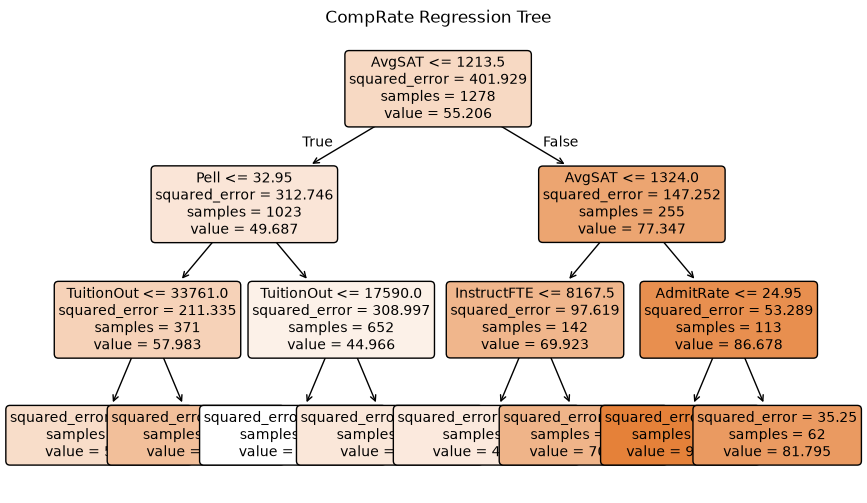

In [8]:
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree

tree = DecisionTreeRegressor(
    max_depth=3,
    min_impurity_decrease=0.008,
    random_state=RANDOM_SEED,
)
tree.fit(X_train, y_train)

plt.figure(figsize=(10, 6))
plot_tree(
    tree,
    feature_names=list(X_train.columns),
    filled=True,
    rounded=True,
    fontsize=10,
)
plt.title("CompRate Regression Tree")
plt.show()

(c) Prune the tree using cross-validation. Compare test MSE of the pruned vs. unpruned tree.

Then grow a second tree using only the public training rows. Do the first two splits match the pooled tree? If not, the pooled tree is averaging different kinds of institution together. Comment on what changed.

(d) Fit a random forest model to the training data.

Choose two different values for mtry (in R) or max features (in Python). If you use R, set importance=TRUE. In Python this is automatic with RandomForestRegressor. Comment on the results.

(e) From the forest in (d): which predictors look most important?

Also name one predictor that is important in the forest but barely appears in the single tree from (b)–(c), and give a one-sentence reason that can happen.

TODO answer (e)

(f) Report the test MSE for the forest and compare it with the pruned tree. Also report test MSE by Control (Public / Private / Profit) for both models. What do you observe?

In [9]:
#TODO complete code to gather analysis for (f)

TODO answer (f)

(g) Fit a GBM. Choose at least two learning rates (shrinkage). In R use distribution="gaussian" in gbm.

Choose the number of trees by cross-validation on the training data. Evaluate that choice once on the test set. You may plot test MSE versus number of trees for the two learning rates as a diagnostic of over/underfitting; do not use that plot to pick the number of trees.

Interpret the two most influential variables.

TODO Interpret the two most influential variables

(h) Fit one linear baseline on encoded features (ordinary least squares or ridge is enough).

Encode categoricals and standardize numerics using the training set only.

Compare test MSE of: mean baseline, Control-mean baseline, pruned tree, forest, GBM, and the linear model. Comment.

TODO comment on (h)

## Part II: Eight schools

From your test set only, choose eight schools and print them: 3 Public, 3 Private, and 2 Profit. Do not pick the eight schools by looking at the residuals or by observed completion. Training-set rows are not allowed.

Then create the following table: Name, Control, Pell, predicted CompRate from your preferred Part I model, observed CompRate, residual (observed minus predicted).

In [10]:
#TODO choose 8 schools and print

#TODO create table described above


Based on your results and the models from Part I, answer the following questions (one or two sentences is sufficient):

(1) Which of the eight schools has the largest absolute residual? Did the model over- or under-predict, and what kind of school is it (using Control and the name)?

TODO answer (1)

(2) Do the errors in your table line up with Control, with missing test scores, or with neither?

TODO answer (2)

(3) These eight numbers are predictions, not a ranking of school quality and not an effect of changing Pell, spending, or admissions. In one sentence, state a conclusion someone might draw from your table that the model does not support.

TODO answer (3)